   ...

   For $n$ bits, the range is -2^(n-1) to 2^(n-1)-1...

   SIGN EXTENSION means copying the MSB when you widen a number. `1011` (-5 in
   4 bits) becomes `11110111` (still -5 in 7 bits). The new bits are all copies
   of the sign bit. This is why the I-type immediate in RISC-V gets 
   "sign-extended" from 12 bits to 32/64 bits -- it preserves the value whether
   positive or negative. 

   OVERFLOW ... The rules... if you add two +ve and get a -ve, or add two -ve,
   and get a +ve, something went wrong... The ALU needs to detect this.


---
2. LOGICAL OPERATIONS   
   Before building the ALU, the lecture catalogs what it needs to support.
                                            <-- `slii` (Shift Left Logical Immediate)
   SHIFTS move all bits left or right by some amount. `slli x10, x16, 8` shifts
   x16 left by 8 bits, filling the empty positions with zeros. Left shift by
   $n$ is equivalent to multiplying by 2^n ... Right shift by n divides by 2^n.

   There's a subtlety with right shifts: `srl` (shift right logical) fills the 
   top with zeros, while `sra` (shift right arithmetic) copies the sign bit. 
   This matters for negative numbers -- `sra` preserves the sign, so 
   -8 >>> 1 = -4 (correct division by 2), while logical right shift would give a
   large +ve number.

   BITWISE OPERATION (`and`, `or`) operate on each pair of corresponding bits
   independently. These are important for masking (isolating specific bits),
   setting flags, and clearing bits -- you used `band` extensively in your
   FunnyCore division code.



---
3. BUILDING BLOCKS: THE GROUND FLOOR
   The ALU needs to compute AND, OR, ADD, and SUB. The lecture builds it from
   the smallest pieces upward.

   INVERTER: flips 0->1 and 1-> 0. Symbol is a triangle with a circle.
   MULTIPLEXER (MUX): a switch. Two inputs (a, b), one control (d), one output.
      If d=0, output=a. If d=1, output=b. You're already familiar with these...
   HIGH-LEVEL ALU STRUCTURE: Two n-bit inputs A and B feed into three parallel
      blocks -- AND gates, OR gates, and an adder. A mux at the output selects
      which result to use. The B input passes through a programmable inverter
      first (for subtraction).      








---

   ... let's rewind to the fundamentals and build up from scratch with real 
   numbers. Carry-out has nothing to do with C++ `cout`... Let's start from the
   very beginning.


WHAT IS A CARRY?
   Think about how you do addition by hand in decimal. If you add 7 + 5, you get
   12 -- you write down the 2 and CARRY THE 1 to the next column. Binary
   addition works exactly the same way, just with 0s and 1s. 

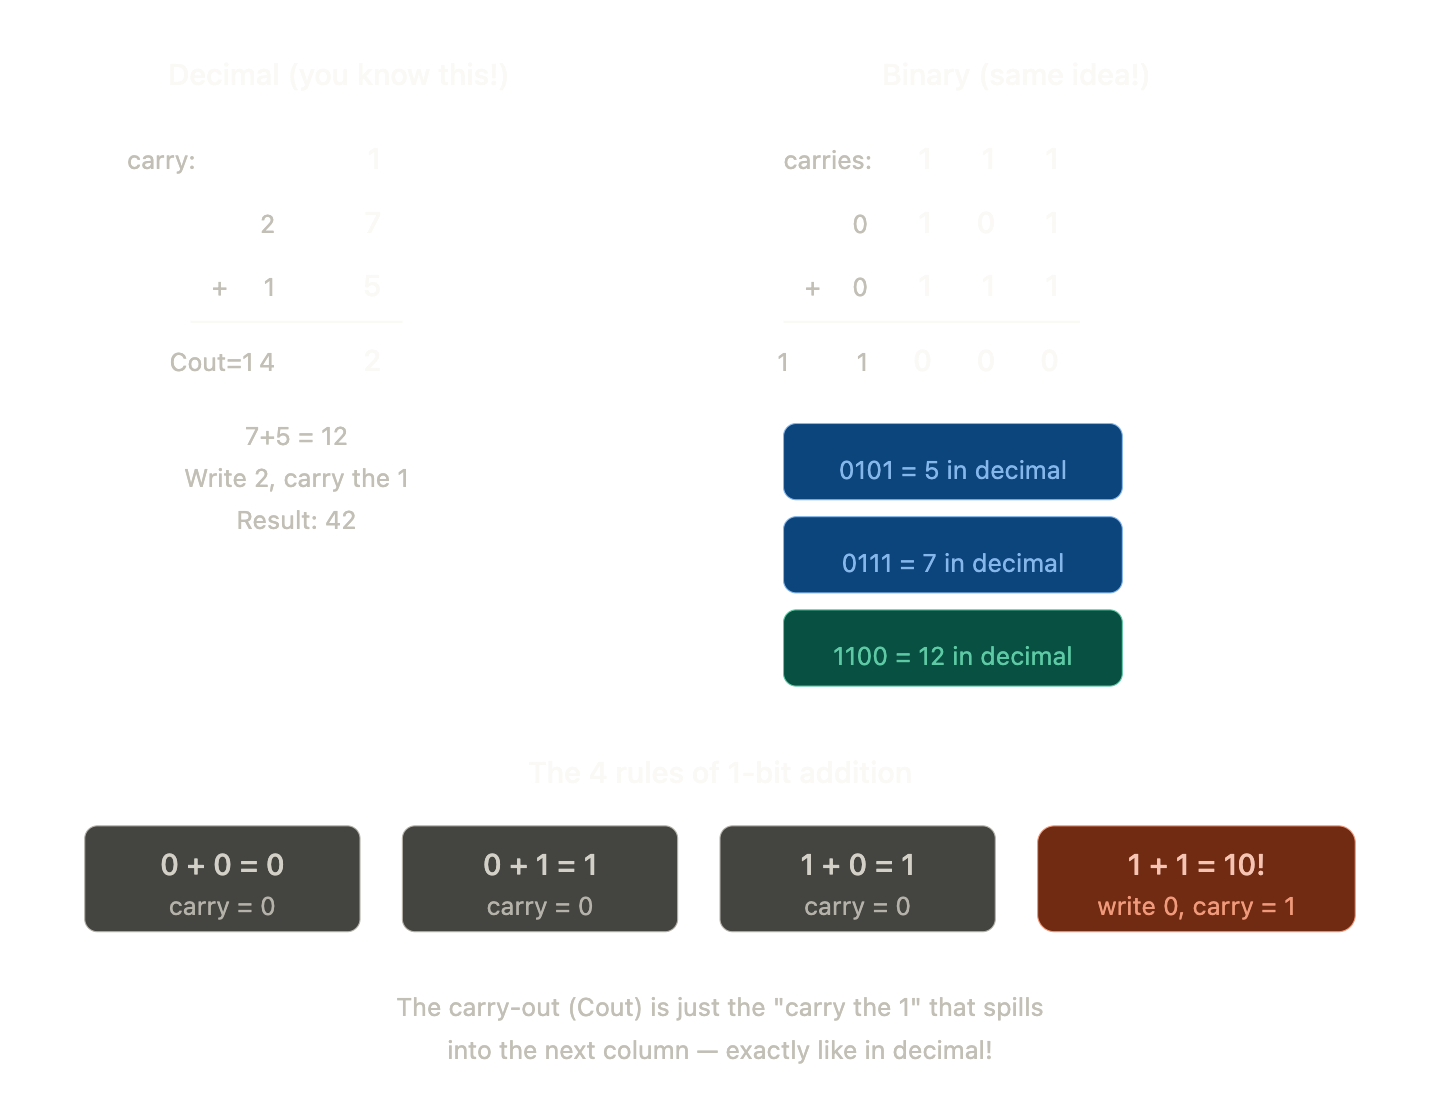

   So CARRY-OUT is just the "carry the 1" from primary school maths, but in
   binary. When 1+1=10 in binary, the 0 stays in the current column and the 1
   gets carried out to the next column. That carried bit is the "carry-out".
   Nothing to do with...

   Now let's ... MUX--this one's actually really intuitive once you see it.


---
WHAT IS A MUX (multiplexor)?
   Think of a MUX as a SWITCH or TV channel selector. Multiple signals come in,
   but only ONE goes through to the output. A control signal decides which one.

   

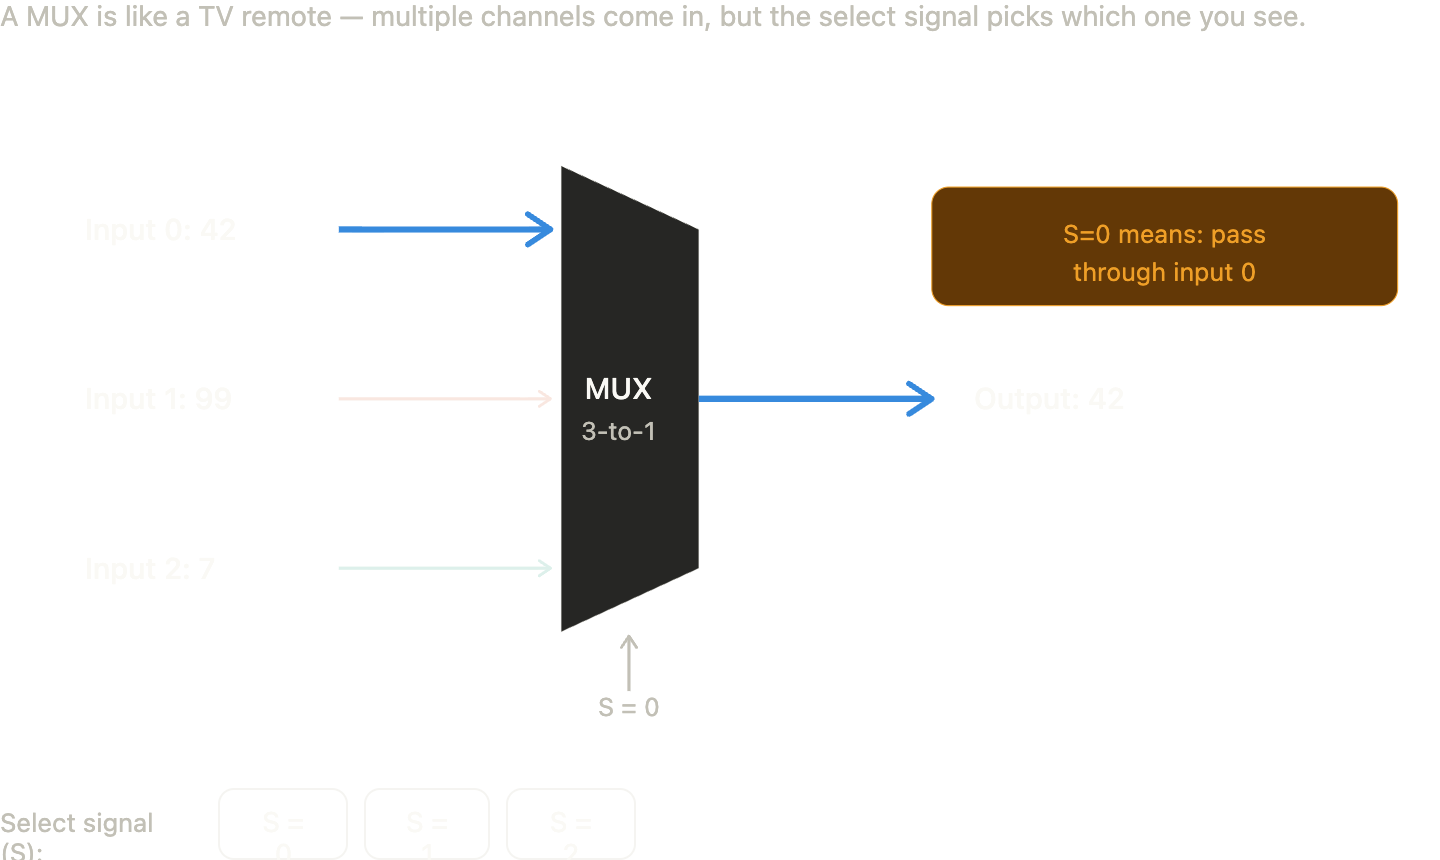

   ... clicking the different $S$ values above -- you'll see how only the
   selected input "passes through" to the output. That's all a MUX is: a
   selector switch controlled by a signal.

   Now that you understand both carry and MUX, let me show you the actual 
   add-subtract circuit from your lecture slide, with REAL NUMBERS FLOWING 
   THROUGH IT so you can see exactly what happens.


### THE ADD-SUBTRACT CIRCUIT IN ACTION   

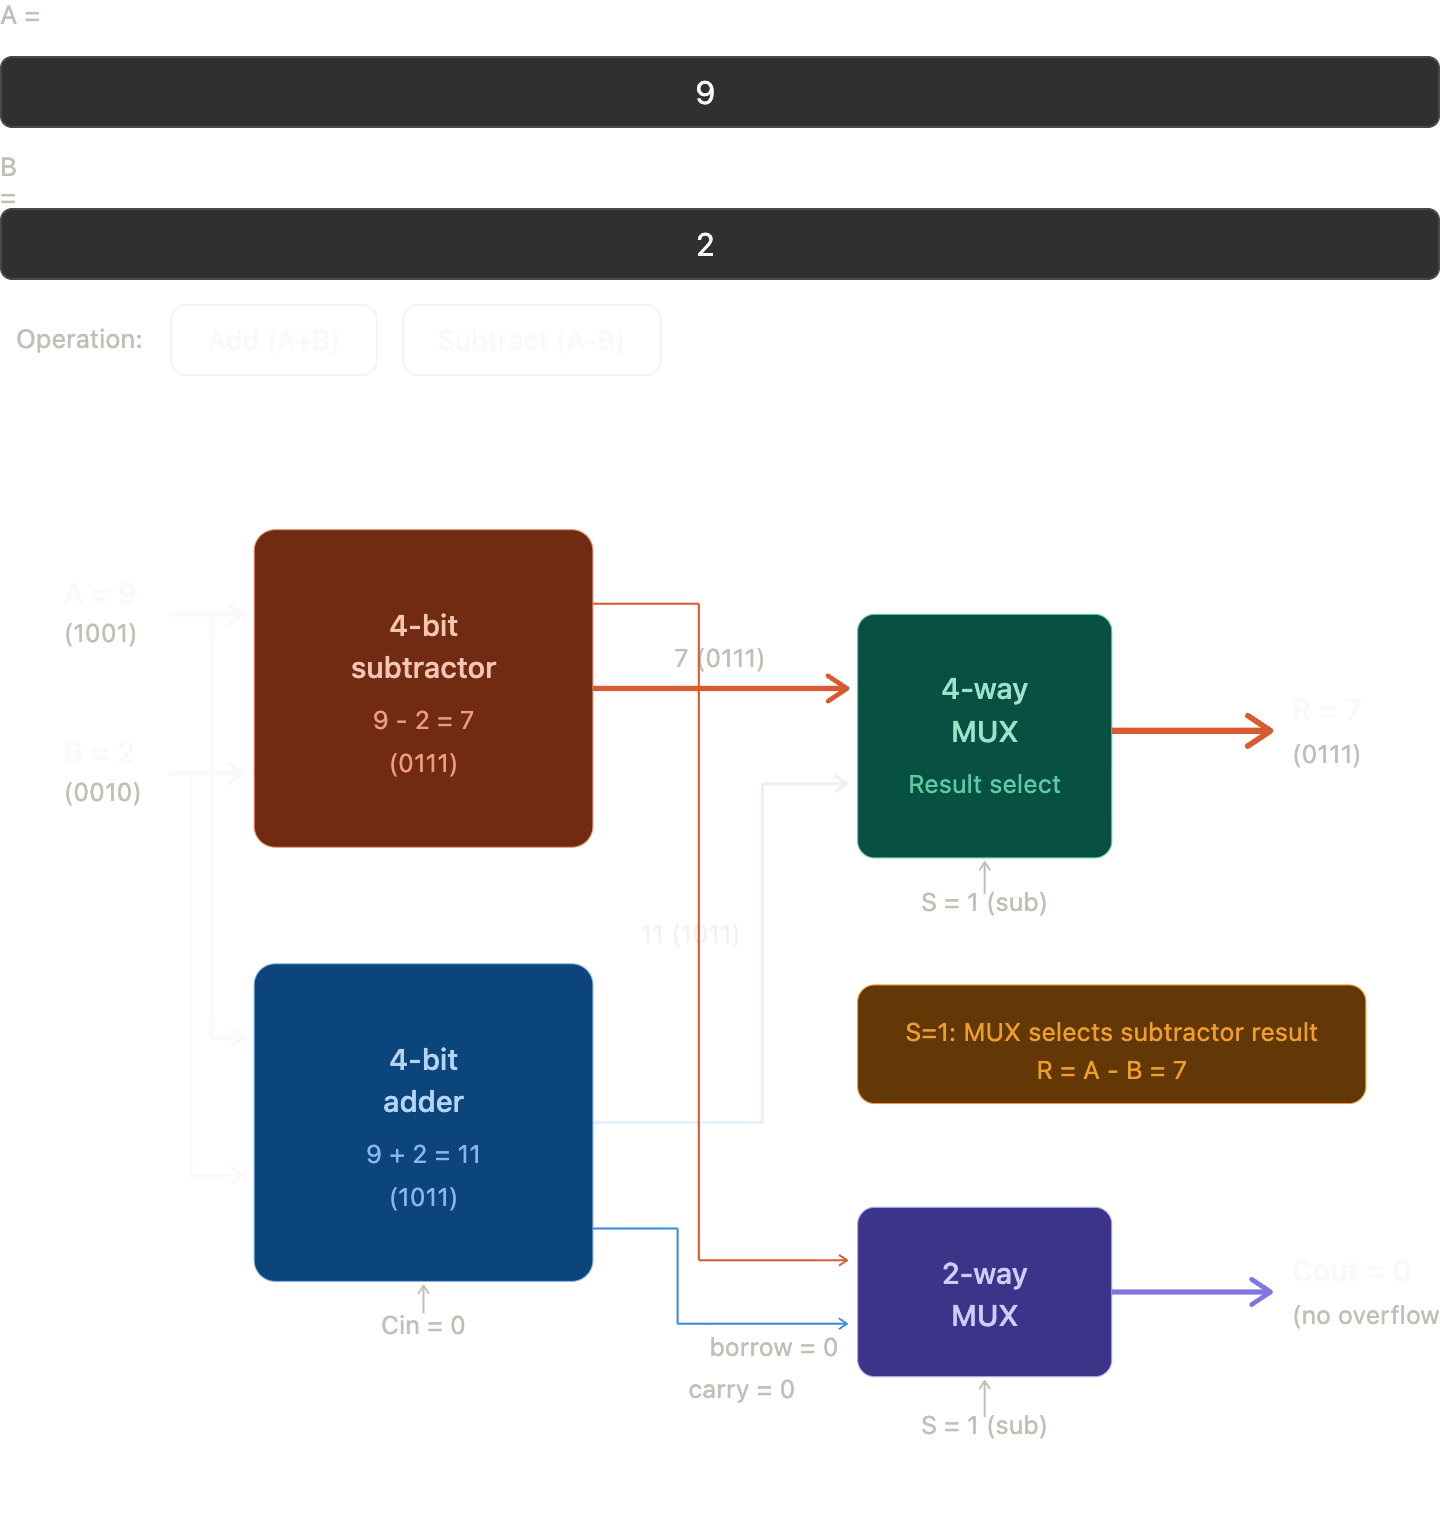

---